### Imports

In [6]:
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

Dimensions: 1920 x 1080


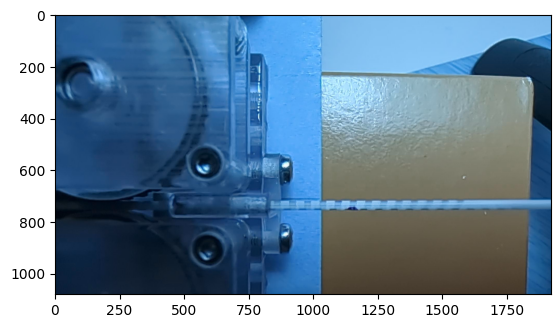

In [20]:
# Stream video from webcam
cap = cv2.VideoCapture(1)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
cap.set(cv2.CAP_PROP_FPS, 60)

# Print dimensions
print(f"Dimensions: {int(cap.get(3))} x {int(cap.get(4))}")

while True:
    success, img = cap.read()
    if not success:
        print("Failed to grab frame")
        break
    cropped = img[680:790, 900:1920]
    cv2.imshow("Video", cropped)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
plt.imshow(img)

In [ ]:
cropped = img[680:790, 900:1920]
plt.imshow(cropped)

In [ ]:
gray_cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
corners = cv2.goodFeaturesToTrack(gray_cropped, 25, 0.01, 10)
corners = np.int0(corners)
for c, corner in enumerate(corners):
    x, y = corner.ravel()
    cv2.circle(gray_cropped, (x, y), 3, 255, -1)
    cv2.putText(gray_cropped, str(c), (x, y-15), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
    
plt.imshow(gray_cropped, cmap='gray')
plt.grid()

In [18]:
# Stream video from webcam
print("Connecting to webcam...")

time_start = time.time()
cap = cv2.VideoCapture(1)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
cap.set(cv2.CAP_PROP_FPS, 60)

print(f"Time to start: {round(time.time() - time_start, 2)} s")
print(f"Dimensions: {int(cap.get(3))} x {int(cap.get(4))}")

x_crop = [900, 1920]
y_crop = [680, 790]

# To select the point to track
while True:
    success, img = cap.read()
    if not success:
        print("Failed to grab frame")
        cap.release()
        cv2.destroyAllWindows()
        exit()
    
    cropped = img[y_crop[0]:y_crop[1], x_crop[0]:x_crop[1]]
    gray_cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    
    corners = cv2.goodFeaturesToTrack(gray_cropped, 25, 0.01, 10)
    if corners is not None:
        corners = np.int0(corners)
        for c, corner in enumerate(corners):
            x, y = corner.ravel()
            cv2.circle(cropped, (x, y), 3, 255, -1)
            cv2.putText(cropped, str(c), (x, y-15), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 1)

    cv2.imshow("Video", cropped)
    cv2.waitKey(1)
    
    response = input("Enter point number or enter to show next frame: ")
    if response:
        point = corners[int(response)].ravel()
        print(f"Selected point: {point}")
        break
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    
# Add video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
now = datetime.now()
out_name = f"output_{now.strftime('%Y%m%d_%H%M%S')}.avi"
out = cv2.VideoWriter(out_name, fourcc, 60.0, (x_crop[1] - x_crop[0], y_crop[1] - y_crop[0]))
    
# Track the selected point
lk_params = dict(winSize=(15, 15), 
                 maxLevel=2, 
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

initial_point = np.array([point], dtype=np.float32)
ret, old_frame = cap.read()
if not ret:
    print("Failed to grab frame")
    cap.release()
    cv2.destroyAllWindows()
    exit()
old_frame = old_frame[y_crop[0]:y_crop[1], x_crop[0]:x_crop[1]]
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

points = np.array([])
time_vidstart = time.time()
time_video = np.array([])
while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break
    frame = frame[y_crop[0]:y_crop[1], x_crop[0]:x_crop[1]]
    
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    new_point, status, error = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, initial_point, None, **lk_params)
    old_gray = frame_gray.copy()
    
    
    
    
    
    
    initial_point = new_point
    x, y = int(new_point.ravel()[0]), int(new_point.ravel()[1])
    
    points = np.append(points, [x, y])
    time_video = np.append(time_video, time.time() - time_vidstart)
    
    cv2.circle(frame, (x, y), 3, 255, -1)
    
    out.write(frame)
    
    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

Connecting to webcam...
Time to start: 27.11 s
Dimensions: 1920 x 1080


C:\Users\2013r\AppData\Local\Temp\ipykernel_35684\2923710256.py:30: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


Selected point: [233  39]


In [19]:
points = points.reshape(-1, 2)
df = pd.DataFrame(time_video, columns=["time"])
df["x"] = points[:, 0]
df["y"] = points[:, 1]
df.to_csv(f"output_{now.strftime('%Y%m%d_%H%M%S')}.csv", index=False)